# Counterfactuals with bivariate beta estimators

First, let us make the necessary imports

In [1]:
import sys
# Add the parent directory to the path to be able to import whatif
sys.path.append("../")

import numpy as np
from matplotlib import pyplot as plt
from whatif import simulate_uplift_bb
from whatif.cf import BivariateBeta, GeneralizedBivariateBeta, NoisyBeta, Simplex4DAxes

/home/tverhels/Dropbox/Documents/PhD/code/What-If/examples/../whatif/cf/bivariate_beta.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


We will generate data artificially instead of using an uplift model on real data. For an example of estimation from real data, see the notebook [Counterfactuals with simple estimators](Counterfactuals_with_simple_estimators.ipynb).
`l_0` and `l_1` dictate the estimator variance of the uplift scores (higher values means less variance), while `m` dictates the distribution of the counterfactuals:
\begin{align}
    \alpha &= \frac{m_1}M \\
    \beta  &= \frac{m_2}M \\
    \gamma &= \frac{m_3}M \\
    \delta &= \frac{m_4}M
\end{align}
with $M=m_1+m_2+m_3+m_4$. Also, larger values of $M$ means that individual counterfactuals are more concentrated around their means (the population counterfactuals), while lower values of $M$ means that the individual counterfactuals are closer to either 0 or 1.

In [2]:
random_state = 12
l_0 = 100
l_1 = 100
m = np.array([50, 3, 3, 1])
mu = m / np.sum(m)
data = simulate_uplift_bb([50, 3, 3, 1], 1000, random_state=12, noise="beta", l_0=l_0, l_1=l_1)

Let's plot the uplift scores to have an idea of their distribution.

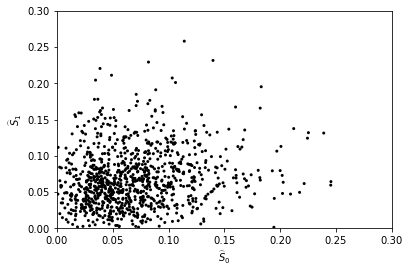

In [3]:
scatter_params = {
    "marker": ".",
    "c": "black",
    "edgecolors": "none"
}

plt.scatter(data.S_0_hat, data.S_1_hat, **scatter_params)
plt.xlabel("$\\widehat S_0$")
plt.ylabel("$\\widehat S_1$")
plt.xlim(0, 0.3)
plt.ylim(0, 0.3)
plt.show()

Now, we fit the four different bivariate beta models: with either Dirichlet distribution (`BivariateBeta`) or generalized Dirichlet distribution (`GeneralizedBivariateBeta`), and either with an attempt to model the estimator variance of the uplift scores (`NoisyBeta`) or not.

In [4]:
model_bb = BivariateBeta()
model_bb.fit(data.S_0_hat, data.S_1_hat)
model_gbb = GeneralizedBivariateBeta()
model_gbb.fit(data.S_0_hat, data.S_1_hat)
model_nbb = NoisyBeta(l_0, l_1, BivariateBeta)
model_nbb.fit(data.S_0_hat, data.S_1_hat)
model_ngbb = NoisyBeta(l_0, l_1, GeneralizedBivariateBeta)
model_ngbb.fit(data.S_0_hat, data.S_1_hat)

2.0381838788597552e-08

To have a visual representation of the fitted distribution, we first compute their probability density function. We use `show_progress=True` because computing the pdf of the `NoisyBeta` distribution takes longer, due to the 2D integrals.

In [5]:
delta = 0.01
X_0 = np.arange(0.001, 0.3, delta)
X_1 = np.arange(0.001, 0.3, delta)
X_0, X_1 = np.meshgrid(X_0, X_1)

pdf_bb = model_bb.pdf(X_0.flatten(), X_1.flatten())
pdf_bb.shape = X_0.shape
pdf_gbb = model_gbb.pdf(X_0.flatten(), X_1.flatten())
pdf_gbb.shape = X_0.shape
pdf_nbb = model_nbb.pdf(X_0.flatten(), X_1.flatten(), show_progress=True)
pdf_nbb.shape = X_0.shape
pdf_ngbb = model_ngbb.pdf(X_0.flatten(), X_1.flatten(), show_progress=True)
pdf_ngbb.shape = X_0.shape

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

And then we plot the pdf as countour plots.

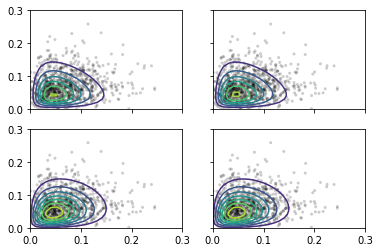

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)

for i, pdf in enumerate([pdf_bb, pdf_gbb, pdf_nbb, pdf_ngbb]):
    axs[i // 2, i % 2].scatter(data.S_0_hat, data.S_1_hat, **scatter_params, alpha=0.2)
    axs[i // 2, i % 2].contour(X_0, X_1, pdf)

plt.xlim(0, 0.3)
plt.ylim(0, 0.3)
plt.show()

The estimated population-level counterfactuals are:

In [7]:
def cf_to_str(mu):
    return "alpha = {:5.1%}, beta = {:5.1%}, gamma = {:5.1%}, delta = {:5.1%}".format(*mu)
model_names = ["BB", "GBB", "NBB", "NGBB"]
for i, model in enumerate([model_bb, model_gbb, model_nbb, model_ngbb]):
    print("{:5} :".format(model_names[i]), cf_to_str(model.population_cf()))
print("truth :", cf_to_str(mu))

BB    : alpha = 86.5%, beta =  6.6%, gamma =  6.5%, delta =  0.4%
GBB   : alpha = 86.5%, beta =  6.6%, gamma =  6.5%, delta =  0.4%
NBB   : alpha = 88.0%, beta =  5.1%, gamma =  5.0%, delta =  1.9%
NGBB  : alpha = 88.0%, beta =  5.0%, gamma =  4.9%, delta =  2.0%
truth : alpha = 87.7%, beta =  5.3%, gamma =  5.3%, delta =  1.8%


We can also compute individual-level counterfactuals: suppose we have a new customer with $S_0=0.1$ and $S_1=0.05$:

In [8]:
for i, model in enumerate([model_bb, model_gbb, model_nbb, model_ngbb]):
    print("{:5} :".format(model_names[i]), cf_to_str(model.individual_cf(np.array([0.1]), np.array([0.05]))[0]))

BB    : alpha = 85.4%, beta =  9.6%, gamma =  4.6%, delta =  0.4%
GBB   : alpha = 85.4%, beta =  9.6%, gamma =  4.6%, delta =  0.4%
NBB   : alpha = 87.3%, beta =  6.8%, gamma =  4.0%, delta =  2.0%
NGBB  : alpha = 87.3%, beta =  6.7%, gamma =  3.9%, delta =  2.1%
